# **Imports and Loading Dataset**

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.metrics import r2_score, accuracy_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split

In [93]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [94]:
df = pd.read_csv("/content/drive/MyDrive/26S/ML/ML PROJECT/REGRESSION_TASK/train_data.csv")
df_test = pd.read_csv("/content/drive/MyDrive/26S/ML/ML PROJECT/REGRESSION_TASK/test_data.csv")

## **Some Initial Insights**

In [95]:
df.head()

,id,Company,Product,TypeName,Inches,ScreenResolution,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,GPU_Type,OpSys,Weight (kg),Price (Euro)
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,2.3,8,128GB SSD,Intel,Iris Plus Graphics 640,macOS,1.37,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel,Core i5,1.8,8,128GB Flash Storage,Intel,HD Graphics 6000,macOS,1.34,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel,Core i5 7200U,2.5,8,256GB SSD,Intel,HD Graphics 620,No OS,1.86,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel,Core i7,2.7,16,512GB SSD,AMD,Radeon Pro 455,macOS,1.83,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,3.1,8,256GB SSD,Intel,Iris Plus Graphics 650,macOS,1.37,1803.60


In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 881 entries, 0 to 880
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   881 non-null    int64  
 1   Company              881 non-null    object 
 2   Product              881 non-null    object 
 3   TypeName             881 non-null    object 
 4   Inches               881 non-null    float64
 5   ScreenResolution     881 non-null    object 
 6   CPU_Company          881 non-null    object 
 7   CPU_Type             881 non-null    object 
 8   CPU_Frequency (GHz)  881 non-null    float64
 9   RAM (GB)             881 non-null    int64  
 10  Memory               881 non-null    object 
 11  GPU_Company          881 non-null    object 
 12  GPU_Type             881 non-null    object 
 13  OpSys                881 non-null    object 
 14  Weight (kg)          881 non-null    float64
 15  Price (Euro)         881 non-null    flo

In [97]:
df.shape

(881, 16)

In [98]:
df.describe()

,id,Inches,CPU_Frequency (GHz),RAM (GB),Weight (kg),Price (Euro)
count,881.00000,881.000000,881.000000,881.000000,881.000000,881.000000
mean,441.00000,15.085017,2.281839,8.522134,2.049714,1110.183235
std,254.46709,1.396360,0.527334,4.921176,0.657077,711.526332
min,1.00000,10.100000,0.900000,2.000000,0.690000,191.900000
25%,221.00000,14.000000,1.800000,4.000000,1.580000,589.000000
50%,441.00000,15.600000,2.500000,8.000000,2.040000,945.000000
75%,661.00000,15.600000,2.700000,8.000000,2.300000,1426.660000
max,881.00000,18.400000,3.600000,32.000000,4.700000,6099.000000


In [99]:
df.duplicated().sum()

np.int64(0)

In [100]:
df.isnull().sum()

,0
id,0
Company,0
Product,0
TypeName,0
Inches,0
ScreenResolution,0
CPU_Company,0
CPU_Type,0
CPU_Frequency (GHz),0
RAM (GB),0


In [101]:
df.drop(columns=['id'], inplace=True)
df_test.drop(columns=['id'], inplace=True)

In [102]:
df.head()

,Company,Product,TypeName,Inches,ScreenResolution,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,GPU_Type,OpSys,Weight (kg),Price (Euro)
0,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,2.3,8,128GB SSD,Intel,Iris Plus Graphics 640,macOS,1.37,1339.69
1,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel,Core i5,1.8,8,128GB Flash Storage,Intel,HD Graphics 6000,macOS,1.34,898.94
2,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel,Core i5 7200U,2.5,8,256GB SSD,Intel,HD Graphics 620,No OS,1.86,575.00
3,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel,Core i7,2.7,16,512GB SSD,AMD,Radeon Pro 455,macOS,1.83,2537.45
4,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,3.1,8,256GB SSD,Intel,Iris Plus Graphics 650,macOS,1.37,1803.60


/tmp/ipykernel_3731/764806980.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Price (Euro)'])


<Axes: xlabel='Price (Euro)', ylabel='Density'>

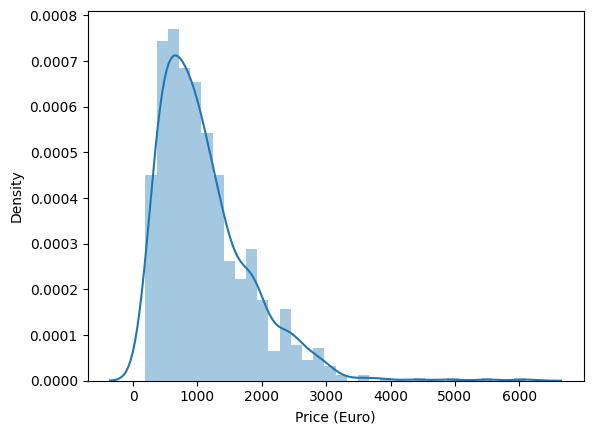

In [103]:
sns.distplot(df['Price (Euro)'])

<Axes: xlabel='Company'>

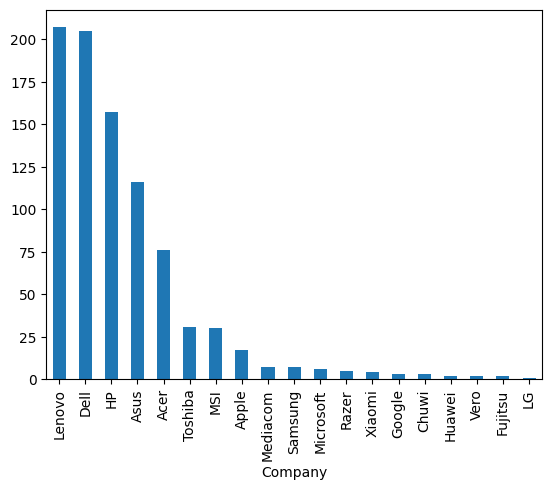

In [104]:
df['Company'].value_counts().plot(kind='bar')

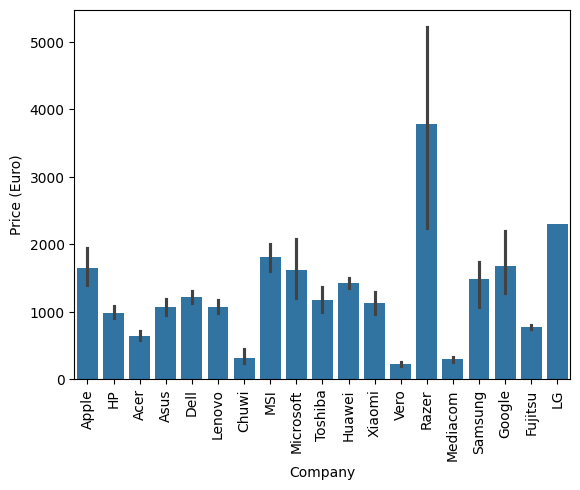

In [105]:
sns.barplot(x=df['Company'],y=df['Price (Euro)'])
plt.xticks(rotation='vertical')
plt.show()

<Axes: xlabel='TypeName'>

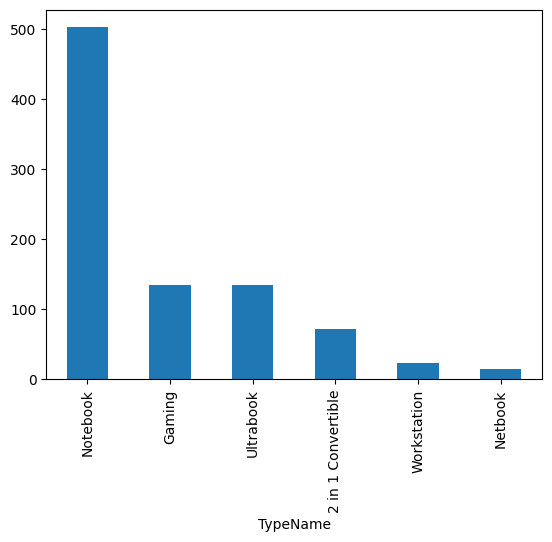

In [106]:
df['TypeName'].value_counts().plot(kind='bar')

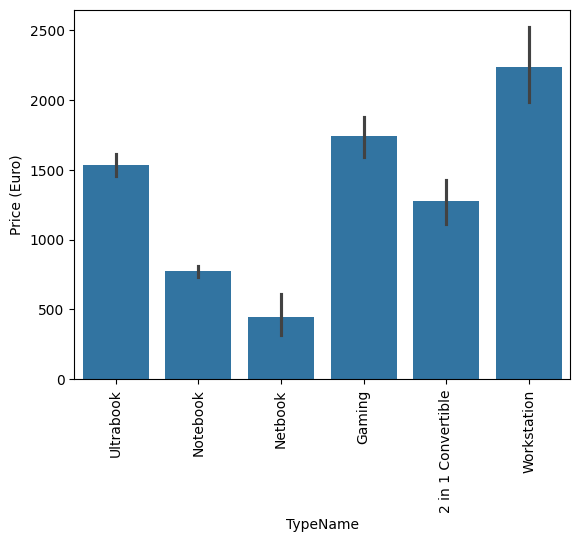

In [107]:
sns.barplot(x=df['TypeName'],y=df['Price (Euro)'])
plt.xticks(rotation='vertical')
plt.show()

/tmp/ipykernel_3731/1439577752.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Inches'])


<Axes: xlabel='Inches', ylabel='Density'>

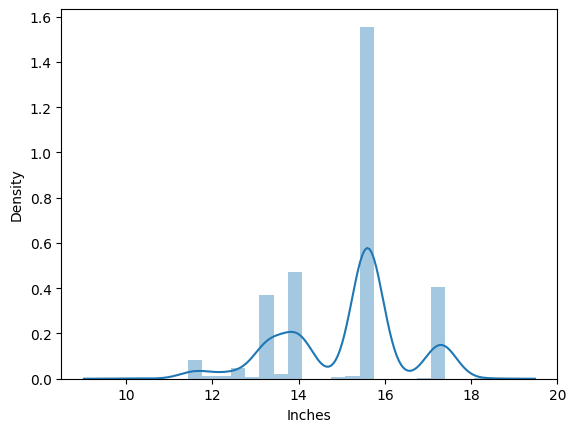

In [108]:
sns.distplot(df['Inches'])

<Axes: xlabel='Inches', ylabel='Price (Euro)'>

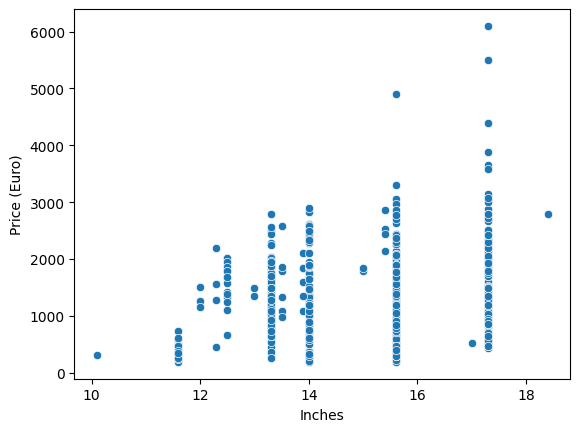

In [109]:
sns.scatterplot(x=df['Inches'],y=df['Price (Euro)'])

# **Feature Engineering**

In [110]:
df['Touchscreen'] = df['ScreenResolution'].apply(lambda x:1 if 'Touchscreen' in x else 0)
df_test['Touchscreen'] = df_test['ScreenResolution'].apply(lambda x:1 if 'Touchscreen' in x else 0)

In [111]:
df.head(20)

,Company,Product,TypeName,Inches,ScreenResolution,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,GPU_Type,OpSys,Weight (kg),Price (Euro),Touchscreen
0,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,2.3,8,128GB SSD,Intel,Iris Plus Graphics 640,macOS,1.37,1339.69,0
1,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel,Core i5,1.8,8,128GB Flash Storage,Intel,HD Graphics 6000,macOS,1.34,898.94,0
2,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel,Core i5 7200U,2.5,8,256GB SSD,Intel,HD Graphics 620,No OS,1.86,575.00,0
3,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel,Core i7,2.7,16,512GB SSD,AMD,Radeon Pro 455,macOS,1.83,2537.45,0
4,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,3.1,8,256GB SSD,Intel,Iris Plus Graphics 650,macOS,1.37,1803.60,0
5,Acer,Aspire 3,Notebook,15.6,1366x768,AMD,A9-Series 9420,3.0,4,500GB HDD,AMD,Radeon R5,Windows 10,2.10,400.00,0
6,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel,Core i7,2.2,16,256GB Flash Storage,Intel,Iris Pro Graphics,Mac OS X,2.04,2139.97,0
7,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel,Core i5,1.8,8,256GB Flash Storage,Intel,HD Graphics 6000,macOS,1.34,1158.70,0
8,Asus,ZenBook UX430UN,Ultrabook,14.0,Full HD 1920x1080,Intel,Core i7 8550U,1.8,16,512GB SSD,Nvidia,GeForce MX150,Windows 10,1.30,1495.00,0
9,Acer,Swift 3,Ultrabook,14.0,IPS Panel Full HD 1920x1080,Intel,Core i5 8250U,1.6,8,256GB SSD,Intel,UHD Graphics 620,Windows 10,1.60,770.00,0


<Axes: xlabel='Touchscreen'>

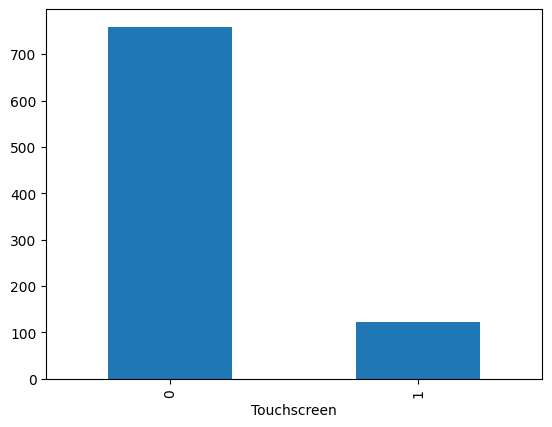

In [112]:
df['Touchscreen'].value_counts().plot(kind='bar')

<Axes: xlabel='Touchscreen', ylabel='Price (Euro)'>

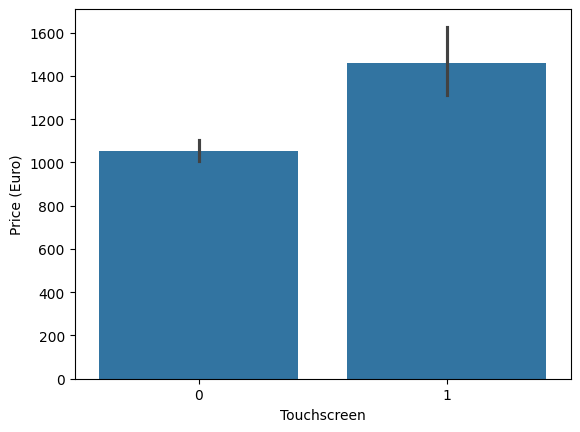

In [113]:
sns.barplot(x=df['Touchscreen'],y=df['Price (Euro)'])

In [114]:
df['Ips'] = df['ScreenResolution'].apply(lambda x:1 if 'IPS' in x else 0)
df_test['Ips'] = df_test['ScreenResolution'].apply(lambda x:1 if 'IPS' in x else 0)

In [115]:
df.head(10)

,Company,Product,TypeName,Inches,ScreenResolution,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,GPU_Type,OpSys,Weight (kg),Price (Euro),Touchscreen,Ips
0,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,2.3,8,128GB SSD,Intel,Iris Plus Graphics 640,macOS,1.37,1339.69,0,1
1,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel,Core i5,1.8,8,128GB Flash Storage,Intel,HD Graphics 6000,macOS,1.34,898.94,0,0
2,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel,Core i5 7200U,2.5,8,256GB SSD,Intel,HD Graphics 620,No OS,1.86,575.00,0,0
3,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel,Core i7,2.7,16,512GB SSD,AMD,Radeon Pro 455,macOS,1.83,2537.45,0,1
4,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,3.1,8,256GB SSD,Intel,Iris Plus Graphics 650,macOS,1.37,1803.60,0,1
5,Acer,Aspire 3,Notebook,15.6,1366x768,AMD,A9-Series 9420,3.0,4,500GB HDD,AMD,Radeon R5,Windows 10,2.10,400.00,0,0
6,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel,Core i7,2.2,16,256GB Flash Storage,Intel,Iris Pro Graphics,Mac OS X,2.04,2139.97,0,1
7,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel,Core i5,1.8,8,256GB Flash Storage,Intel,HD Graphics 6000,macOS,1.34,1158.70,0,0
8,Asus,ZenBook UX430UN,Ultrabook,14.0,Full HD 1920x1080,Intel,Core i7 8550U,1.8,16,512GB SSD,Nvidia,GeForce MX150,Windows 10,1.30,1495.00,0,0
9,Acer,Swift 3,Ultrabook,14.0,IPS Panel Full HD 1920x1080,Intel,Core i5 8250U,1.6,8,256GB SSD,Intel,UHD Graphics 620,Windows 10,1.60,770.00,0,1


<Axes: xlabel='Ips'>

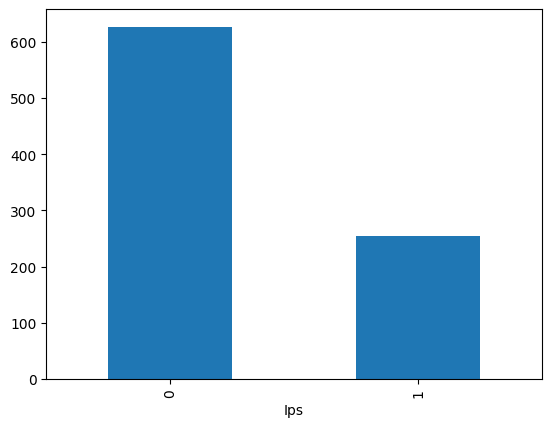

In [116]:
df['Ips'].value_counts().plot(kind='bar')

<Axes: xlabel='Ips', ylabel='Price (Euro)'>

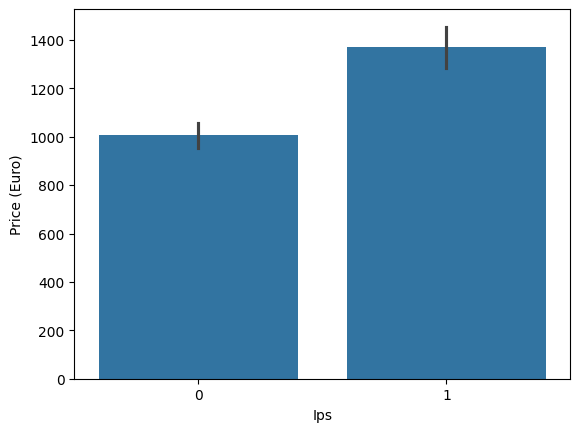

In [117]:
sns.barplot(x=df['Ips'],y=df['Price (Euro)'])

In [118]:
df[['X_res', 'Y_res']] = df['ScreenResolution'].str.extract(r'(\d+)x(\d+)').astype(int)
df_test[['X_res', 'Y_res']] = df_test['ScreenResolution'].str.extract(r'(\d+)x(\d+)').astype(int)

In [119]:
df.sample(10)

,Company,Product,TypeName,Inches,ScreenResolution,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,GPU_Type,OpSys,Weight (kg),Price (Euro),Touchscreen,Ips,X_res,Y_res
184,Xiaomi,Mi Notebook,Notebook,15.6,IPS Panel Full HD 1920x1080,Intel,Core i5 8250U,1.6,8,256GB SSD,Nvidia,GeForce MX150,No OS,1.95,1199.00,0,1,1920,1080
445,Dell,Latitude 5480,Notebook,14.0,Full HD 1920x1080,Intel,Core i5 7440HQ,2.8,8,256GB SSD,Nvidia,GeForce 930MX,Windows 10,1.64,1179.00,0,0,1920,1080
449,Microsoft,Surface Laptop,Ultrabook,13.5,Touchscreen 2256x1504,Intel,Core i7 7660U,2.5,16,512GB SSD,Intel,Iris Plus Graphics 640,Windows 10 S,1.25,2589.00,1,0,2256,1504
250,Dell,Inspiron 5579,2 in 1 Convertible,15.6,IPS Panel Full HD / Touchscreen 1920x1080,Intel,Core i7 8550U,1.8,8,1TB HDD,Intel,UHD Graphics 620,Windows 10,2.08,819.00,1,1,1920,1080
42,Asus,X542UQ-GO005 (i5-7200U/8GB/1TB/GeForce,Notebook,15.6,1366x768,Intel,Core i5 7200U,2.5,8,1TB HDD,Nvidia,GeForce 940MX,Linux,2.30,522.99,0,0,1366,768
166,Acer,Aspire 3,Notebook,15.6,1366x768,Intel,Pentium Quad Core N4200,1.1,4,1TB HDD,Intel,HD Graphics 505,Windows 10,2.10,363.51,0,0,1366,768
252,Asus,X505BP-BR019T (A9-9420/4GB/1TB/Radeon,Notebook,15.6,1366x768,AMD,A9-Series 9420,3.0,4,1TB HDD,AMD,Radeon R5 M420,Windows 10,1.68,469.00,0,0,1366,768
628,Asus,Q304UA-BHI5T11 (i5-7200U/6GB/1TB/FHD/W10),2 in 1 Convertible,13.3,Full HD / Touchscreen 1920x1080,Intel,Core i5 7200U,2.5,6,1TB HDD,Intel,HD Graphics 620,Windows 10,1.50,639.01,1,0,1920,1080
4,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,3.1,8,256GB SSD,Intel,Iris Plus Graphics 650,macOS,1.37,1803.60,0,1,2560,1600
819,Dell,Latitude 3480,Notebook,14.0,1366x768,Intel,Core i5 6200U,2.3,4,500GB HDD,Intel,HD Graphics 520,Windows 10,1.76,755.00,0,0,1366,768


In [120]:
df.sample(10)

,Company,Product,TypeName,Inches,ScreenResolution,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,GPU_Type,OpSys,Weight (kg),Price (Euro),Touchscreen,Ips,X_res,Y_res
831,Lenovo,Thinkpad X1,Ultrabook,14.0,IPS Panel Quad HD+ 2560x1440,Intel,Core i7 6600U,2.6,16,512GB SSD,Intel,HD Graphics 520,Windows 10,1.10,2099.00,0,1,2560,1440
275,Dell,Inspiron 5567,Notebook,15.6,1366x768,Intel,Core i7 7500U,2.7,12,1TB HDD,Intel,HD Graphics 620,Windows 10,2.30,713.07,0,0,1366,768
248,HP,ProBook 430,Notebook,13.3,IPS Panel Full HD 1920x1080,Intel,Core i5 8250U,1.6,4,500GB HDD,Intel,UHD Graphics 620,Windows 10,1.49,675.00,0,1,1920,1080
257,HP,Envy 17-U275cl,Notebook,17.3,IPS Panel Full HD 1920x1080,Intel,Core i7 8550U,1.8,16,1TB HDD,Nvidia,GeForce MX150,Windows 10,2.90,1059.00,0,1,1920,1080
416,Dell,Latitude 3380,Notebook,13.3,1366x768,Intel,Core i3 6006U,2.0,4,128GB SSD,Intel,HD Graphics 520,Windows 10,1.65,689.00,0,0,1366,768
199,HP,Probook 470,Notebook,17.3,Full HD 1920x1080,Intel,Core i7 8550U,1.8,8,256GB SSD,Nvidia,GeForce 930MX,Windows 10,2.50,1045.00,0,0,1920,1080
773,Dell,Inspiron 7567,Gaming,15.6,Full HD 1920x1080,Intel,Core i7 7700HQ,2.8,8,1TB HDD,Nvidia,GeForce GTX 1050,Windows 10,2.62,1099.00,0,0,1920,1080
159,Toshiba,Satellite Pro,Notebook,15.6,1366x768,Intel,Core i3 6006U,2.2,4,500GB HDD,Intel,HD Graphics 520,Windows 10,2.10,447.00,0,0,1366,768
154,HP,EliteBook 840,Ultrabook,14.0,Full HD 1920x1080,Intel,Core i5 7500U,2.7,4,256GB SSD,Intel,HD Graphics 620,Windows 10,1.48,1082.00,0,0,1920,1080
311,Dell,XPS 13,Ultrabook,13.3,IPS Panel 4K Ultra HD / Touchscreen 3840x2160,Intel,Core i7 8550U,1.8,16,1TB SSD,Intel,UHD Graphics 620,Windows 10,1.21,2499.00,1,1,3840,2160


In [121]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 881 entries, 0 to 880
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Company              881 non-null    object 
 1   Product              881 non-null    object 
 2   TypeName             881 non-null    object 
 3   Inches               881 non-null    float64
 4   ScreenResolution     881 non-null    object 
 5   CPU_Company          881 non-null    object 
 6   CPU_Type             881 non-null    object 
 7   CPU_Frequency (GHz)  881 non-null    float64
 8   RAM (GB)             881 non-null    int64  
 9   Memory               881 non-null    object 
 10  GPU_Company          881 non-null    object 
 11  GPU_Type             881 non-null    object 
 12  OpSys                881 non-null    object 
 13  Weight (kg)          881 non-null    float64
 14  Price (Euro)         881 non-null    float64
 15  Touchscreen          881 non-null    int

In [122]:
df['ppi'] = (((df['X_res']**2) + (df['Y_res']**2))**0.5/df['Inches']).astype('float')
df_test['ppi'] = (((df_test['X_res']**2) + (df_test['Y_res']**2))**0.5/df_test['Inches']).astype('float')

df['ppi']=df['ppi'].fillna(df['ppi'].mean())
df_test['ppi']=df_test['ppi'].fillna(df['ppi'].mean())

<Axes: xlabel='ppi', ylabel='Price (Euro)'>

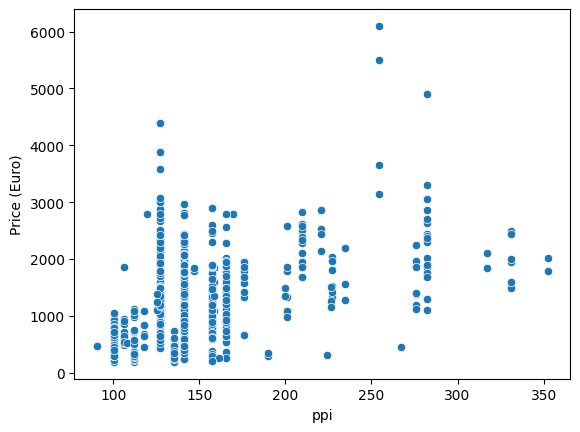

In [123]:
sns.scatterplot(x=df['ppi'],y=df['Price (Euro)'])

In [124]:
df['X_res'].sample(10)

,X_res
728,1366
453,1920
114,1920
126,1920
341,1920
787,1920
594,1920
287,1920
751,1920
218,1920


In [125]:
df['X_res'].value_counts()

,count
X_res,
1920,597
1366,184
3840,33
2560,19
1600,16
3200,9
2256,6
2880,4
1440,4


In [126]:
df['Y_res'].value_counts()

,count
Y_res,
1080,595
768,184
2160,33
900,20
1440,18
1800,13
1600,9
1504,6
1200,2


In [127]:
df.corr(numeric_only=True)['Price (Euro)']

,Price (Euro)
Inches,0.092347
CPU_Frequency (GHz),0.451539
RAM (GB),0.784077
Weight (kg),0.241972
Price (Euro),1.000000
Touchscreen,0.198150
Ips,0.232332
X_res,0.574924
Y_res,0.572712
ppi,0.490622


In [128]:
df.drop(columns=['ScreenResolution','Inches','X_res','Y_res'],inplace=True)
df_test.drop(columns=['ScreenResolution','Inches','X_res','Y_res'],inplace=True)

In [129]:
df.head()

,Company,Product,TypeName,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,GPU_Type,OpSys,Weight (kg),Price (Euro),Touchscreen,Ips,ppi
0,Apple,MacBook Pro,Ultrabook,Intel,Core i5,2.3,8,128GB SSD,Intel,Iris Plus Graphics 640,macOS,1.37,1339.69,0,1,226.983005
1,Apple,Macbook Air,Ultrabook,Intel,Core i5,1.8,8,128GB Flash Storage,Intel,HD Graphics 6000,macOS,1.34,898.94,0,0,127.677940
2,HP,250 G6,Notebook,Intel,Core i5 7200U,2.5,8,256GB SSD,Intel,HD Graphics 620,No OS,1.86,575.00,0,0,141.211998
3,Apple,MacBook Pro,Ultrabook,Intel,Core i7,2.7,16,512GB SSD,AMD,Radeon Pro 455,macOS,1.83,2537.45,0,1,220.534624
4,Apple,MacBook Pro,Ultrabook,Intel,Core i5,3.1,8,256GB SSD,Intel,Iris Plus Graphics 650,macOS,1.37,1803.60,0,1,226.983005


In [130]:
df.drop(columns=['Product'],inplace=True)
df_test.drop(columns=['Product'],inplace=True)

In [131]:
df['CPU_Company'].value_counts().head(50)

,count
CPU_Company,
Intel,835
AMD,46


In [132]:
df['CPU_Type'].value_counts().head(50)

,count
CPU_Type,
Core i5 7200U,134
Core i7 7700HQ,117
Core i7 7500U,91
Core i5 8250U,71
Core i7 8550U,71
Core i3 6006U,63
Core i5 7300HQ,28
Celeron Dual Core N3350,27
Core i3 7100U,24


In [133]:
df['CPU'] = df['CPU_Type'].str.extract(r'(Core i[3579]|Core M|Ryzen|Xeon|Celeron|Pentium|Atom|A\d+-Series|E-Series|FX)')
df_test['CPU'] = df_test['CPU_Type'].str.extract(r'(Core i[3579]|Core M|Ryzen|Xeon|Celeron|Pentium|Atom|A\d+-Series|E-Series|FX)')

In [134]:
df['CPU'].value_counts().head(50)

,count
CPU,
Core i7,350
Core i5,292
Core i3,98
Celeron,57
Pentium,19
A9-Series,13
Atom,8
A6-Series,8
E-Series,7


<Axes: xlabel='CPU'>

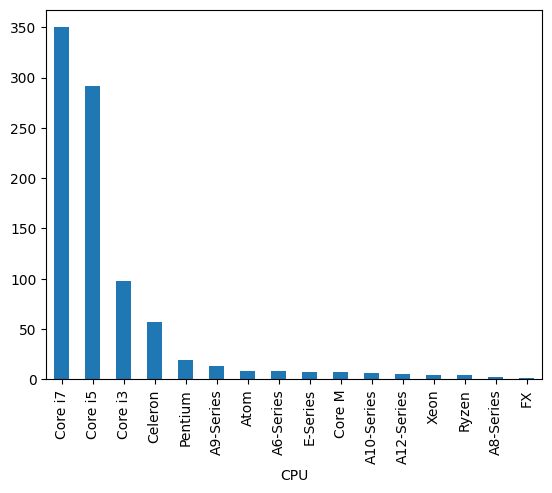

In [135]:
df['CPU'].value_counts().plot(kind='bar')

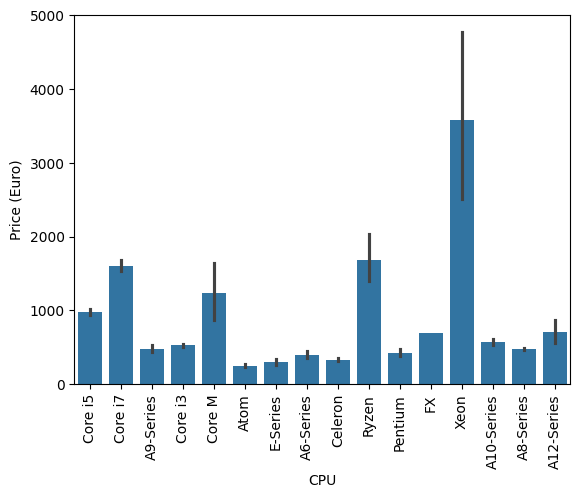

In [136]:
sns.barplot(x=df['CPU'],y=df['Price (Euro)'])
plt.xticks(rotation='vertical')
plt.show()

<Axes: xlabel='RAM (GB)'>

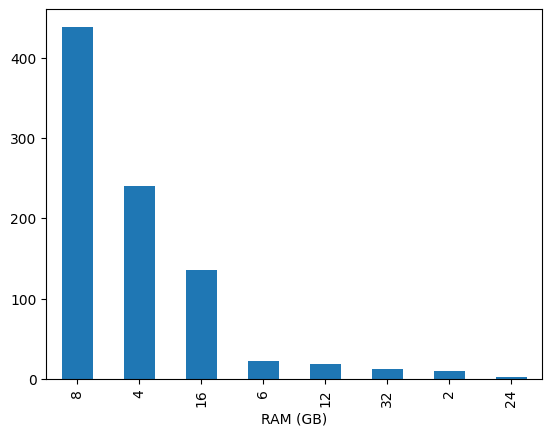

In [137]:
df['RAM (GB)'].value_counts().plot(kind='bar')

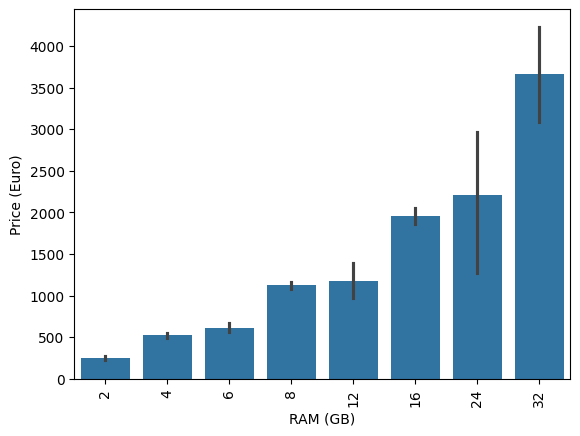

In [138]:
sns.barplot(x=df['RAM (GB)'],y=df['Price (Euro)'])
plt.xticks(rotation='vertical')
plt.show()

In [139]:
df['Memory'].value_counts()

,count
Memory,
256GB SSD,287
1TB HDD,155
512GB SSD,83
500GB HDD,69
128GB SSD + 1TB HDD,63
128GB SSD,59
256GB SSD + 1TB HDD,48
32GB Flash Storage,25
2TB HDD,14


In [140]:
df['Memory'] = df['Memory'].astype(str).replace(r'\.0', '', regex=True)
df["Memory"] = df["Memory"].str.replace('GB', '')
df["Memory"] = df["Memory"].str.replace('TB', '000')
new = df["Memory"].str.split("+", n = 1, expand = True)

df["first"]= new[0]
df["first"]=df["first"].str.strip()

df["second"]= new[1]

df["Layer1HDD"] = df["first"].apply(lambda x: 1 if "HDD" in x else 0)
df["Layer1SSD"] = df["first"].apply(lambda x: 1 if "SSD" in x else 0)
df["Layer1Hybrid"] = df["first"].apply(lambda x: 1 if "Hybrid" in x else 0)
df["Layer1Flash_Storage"] = df["first"].apply(lambda x: 1 if "Flash Storage" in x else 0)

df['first'] = df['first'].str.replace(r'\D', '', regex=True)

df["second"] = df["second"].fillna("0")

df["Layer2HDD"] = df["second"].apply(lambda x: 1 if "HDD" in x else 0)
df["Layer2SSD"] = df["second"].apply(lambda x: 1 if "SSD" in x else 0)
df["Layer2Hybrid"] = df["second"].apply(lambda x: 1 if "Hybrid" in x else 0)
df["Layer2Flash_Storage"] = df["second"].apply(lambda x: 1 if "Flash Storage" in x else 0)

df['second'] = df['second'].str.replace(r'\D', '', regex=True)

df["first"] = df["first"].astype(int)
df["second"] = df["second"].astype(int)

df["HDD"]=(df["first"]*df["Layer1HDD"]+df["second"]*df["Layer2HDD"])
df["SSD"]=(df["first"]*df["Layer1SSD"]+df["second"]*df["Layer2SSD"])
df["Hybrid"]=(df["first"]*df["Layer1Hybrid"]+df["second"]*df["Layer2Hybrid"])
df["Flash_Storage"]=(df["first"]*df["Layer1Flash_Storage"]+df["second"]*df["Layer2Flash_Storage"])

df.drop(columns=['first', 'second', 'Layer1HDD', 'Layer1SSD', 'Layer1Hybrid',
       'Layer1Flash_Storage', 'Layer2HDD', 'Layer2SSD', 'Layer2Hybrid',
       'Layer2Flash_Storage'],inplace=True)

In [141]:
df_test['Memory'] = df_test['Memory'].astype(str).replace(r'\.0', '', regex=True)
df_test["Memory"] = df_test["Memory"].str.replace('GB', '')
df_test["Memory"] = df_test["Memory"].str.replace('TB', '000')
new_test = df_test["Memory"].str.split("+", n = 1, expand = True)

df_test["first"]= new_test[0]
df_test["first"]=df_test["first"].str.strip()

df_test["second"]= new_test[1]

df_test["Layer1HDD"] = df_test["first"].apply(lambda x: 1 if "HDD" in x else 0)
df_test["Layer1SSD"] = df_test["first"].apply(lambda x: 1 if "SSD" in x else 0)
df_test["Layer1Hybrid"] = df_test["first"].apply(lambda x: 1 if "Hybrid" in x else 0)
df_test["Layer1Flash_Storage"] = df_test["first"].apply(lambda x: 1 if "Flash Storage" in x else 0)

df_test['first'] = df_test['first'].str.replace(r'\D', '', regex=True)

df_test["second"] = df_test["second"].fillna("0")

df_test["Layer2HDD"] = df_test["second"].apply(lambda x: 1 if "HDD" in x else 0)
df_test["Layer2SSD"] = df_test["second"].apply(lambda x: 1 if "SSD" in x else 0)
df_test["Layer2Hybrid"] = df_test["second"].apply(lambda x: 1 if "Hybrid" in x else 0)
df_test["Layer2Flash_Storage"] = df_test["second"].apply(lambda x: 1 if "Flash Storage" in x else 0)

df_test['second'] = df_test['second'].str.replace(r'\D', '', regex=True)

df_test["first"] = df_test["first"].astype(int)
df_test["second"] = df_test["second"].astype(int)

df_test["HDD"]=(df_test["first"]*df_test["Layer1HDD"]+df_test["second"]*df_test["Layer2HDD"])
df_test["SSD"]=(df_test["first"]*df_test["Layer1SSD"]+df_test["second"]*df_test["Layer2SSD"])
df_test["Hybrid"]=(df_test["first"]*df_test["Layer1Hybrid"]+df_test["second"]*df_test["Layer2Hybrid"])
df_test["Flash_Storage"]=(df_test["first"]*df_test["Layer1Flash_Storage"]+df_test["second"]*df_test["Layer2Flash_Storage"])

df_test.drop(columns=['first', 'second', 'Layer1HDD', 'Layer1SSD', 'Layer1Hybrid',
       'Layer1Flash_Storage', 'Layer2HDD', 'Layer2SSD', 'Layer2Hybrid',
       'Layer2Flash_Storage'],inplace=True)

In [142]:
df.head()

,Company,TypeName,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,GPU_Type,OpSys,Weight (kg),Price (Euro),Touchscreen,Ips,ppi,CPU,HDD,SSD,Hybrid,Flash_Storage
0,Apple,Ultrabook,Intel,Core i5,2.3,8,128 SSD,Intel,Iris Plus Graphics 640,macOS,1.37,1339.69,0,1,226.983005,Core i5,0,128,0,0
1,Apple,Ultrabook,Intel,Core i5,1.8,8,128 Flash Storage,Intel,HD Graphics 6000,macOS,1.34,898.94,0,0,127.677940,Core i5,0,0,0,128
2,HP,Notebook,Intel,Core i5 7200U,2.5,8,256 SSD,Intel,HD Graphics 620,No OS,1.86,575.00,0,0,141.211998,Core i5,0,256,0,0
3,Apple,Ultrabook,Intel,Core i7,2.7,16,512 SSD,AMD,Radeon Pro 455,macOS,1.83,2537.45,0,1,220.534624,Core i7,0,512,0,0
4,Apple,Ultrabook,Intel,Core i5,3.1,8,256 SSD,Intel,Iris Plus Graphics 650,macOS,1.37,1803.60,0,1,226.983005,Core i5,0,256,0,0


In [143]:
df.drop(columns=['Memory'],inplace=True)
df_test.drop(columns=['Memory'],inplace=True)

In [144]:
df.corr(numeric_only=True)['Price (Euro)']

,Price (Euro)
CPU_Frequency (GHz),0.451539
RAM (GB),0.784077
Weight (kg),0.241972
Price (Euro),1.000000
Touchscreen,0.198150
Ips,0.232332
ppi,0.490622
HDD,-0.084962
SSD,0.677730
Hybrid,-0.010011


In [145]:
df.drop(columns=['Hybrid','Flash_Storage'],inplace=True)
df_test.drop(columns=['Hybrid','Flash_Storage'],inplace=True)

In [146]:
df['GPU_Type'].value_counts()

,count
GPU_Type,
HD Graphics 620,197
HD Graphics 520,83
UHD Graphics 620,66
GeForce GTX 1050,54
Radeon 530,37
...,...
Radeon R7 Graphics,1
GeForce 920,1
GeForce 940M,1


In [147]:
df['GPU_Company'].value_counts()

,count
GPU_Company,
Intel,464
Nvidia,283
AMD,134


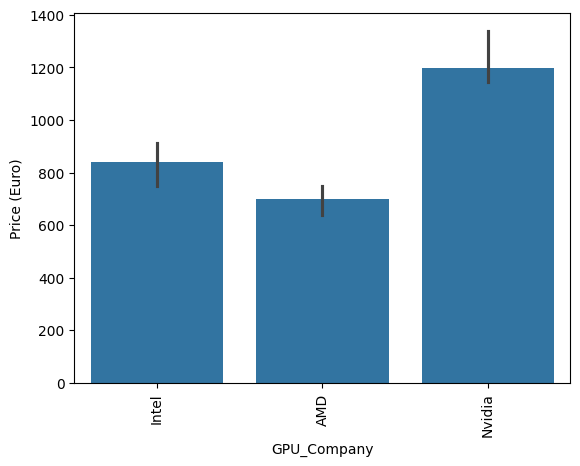

In [148]:
sns.barplot(x=df['GPU_Company'],y=df['Price (Euro)'],estimator=np.median)
plt.xticks(rotation='vertical')
plt.show()

In [149]:
df.drop(columns=['GPU_Type'],inplace=True)
df_test.drop(columns=['GPU_Type'],inplace=True)

In [150]:
df.drop(columns=['CPU_Type'],inplace=True)
df_test.drop(columns=['CPU_Type'],inplace=True)

In [151]:
df.sample(10)

,Company,TypeName,CPU_Company,CPU_Frequency (GHz),RAM (GB),GPU_Company,OpSys,Weight (kg),Price (Euro),Touchscreen,Ips,ppi,CPU,HDD,SSD
78,Acer,Notebook,Intel,2.7,4,Nvidia,Windows 10,2.20,530.0,0,0,141.211998,Core i3,1000,0
107,Asus,Ultrabook,Intel,2.7,8,Nvidia,Windows 10,1.30,1193.0,0,1,157.350512,Core i7,0,256
625,Lenovo,Notebook,Intel,2.7,8,Nvidia,Windows 10,2.20,899.0,0,0,141.211998,Core i7,1000,0
246,HP,Notebook,Intel,2.5,8,Intel,Windows 10,2.04,559.0,1,0,100.454670,Core i5,1000,0
208,Dell,Ultrabook,Intel,1.8,8,Intel,Windows 10,1.20,1449.0,0,0,165.632118,Core i7,0,256
71,Dell,Ultrabook,Intel,1.8,8,AMD,Windows 10,1.40,955.0,0,1,165.632118,Core i7,0,256
405,Asus,Ultrabook,Intel,2.7,8,Intel,Windows 10,1.10,1873.0,0,0,157.350512,Core i7,0,512
295,Lenovo,Gaming,Intel,2.8,8,Nvidia,Windows 10,3.20,1299.0,0,1,141.211998,Core i7,1000,0
590,Asus,2 in 1 Convertible,Intel,2.5,8,Intel,Windows 10,2.20,739.0,1,0,100.454670,Core i5,1000,0
172,Lenovo,Notebook,AMD,2.9,4,AMD,No OS,2.20,309.0,0,0,100.454670,A6-Series,500,0


In [152]:
df['TypeName'].value_counts()

,count
TypeName,
Notebook,503
Gaming,135
Ultrabook,134
2 in 1 Convertible,72
Workstation,23
Netbook,14


In [153]:
df['OpSys'].value_counts()

,count
OpSys,
Windows 10,735
No OS,50
Linux,45
Chrome OS,17
macOS,13
Windows 7,8
Windows 10 S,8
Mac OS X,4
Android,1


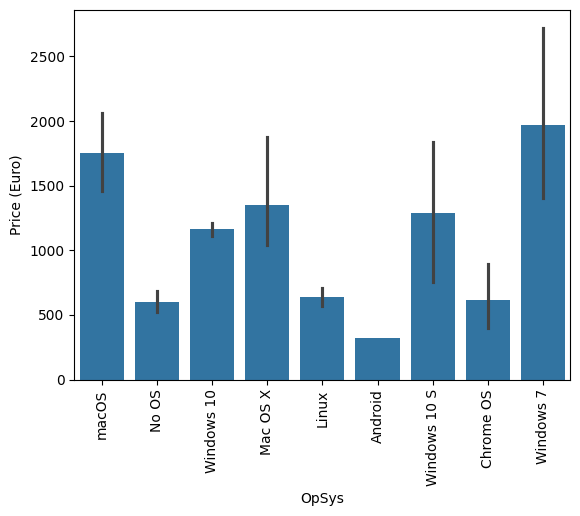

In [154]:
sns.barplot(x=df['OpSys'],y=df['Price (Euro)'])
plt.xticks(rotation='vertical')
plt.show()

In [155]:
def cat_os(inp):
    if inp == 'Windows 10' or inp == 'Windows 7' or inp == 'Windows 10 S':
        return 'Windows'
    elif inp == 'macOS' or inp == 'Mac OS X':
        return 'Mac'
    else:
        return 'Other'

In [156]:
df['OS'] = df['OpSys'].apply(cat_os)
df_test['OS'] = df_test['OpSys'].apply(cat_os)

In [157]:
df.head()

,Company,TypeName,CPU_Company,CPU_Frequency (GHz),RAM (GB),GPU_Company,OpSys,Weight (kg),Price (Euro),Touchscreen,Ips,ppi,CPU,HDD,SSD,OS
0,Apple,Ultrabook,Intel,2.3,8,Intel,macOS,1.37,1339.69,0,1,226.983005,Core i5,0,128,Mac
1,Apple,Ultrabook,Intel,1.8,8,Intel,macOS,1.34,898.94,0,0,127.677940,Core i5,0,0,Mac
2,HP,Notebook,Intel,2.5,8,Intel,No OS,1.86,575.00,0,0,141.211998,Core i5,0,256,Other
3,Apple,Ultrabook,Intel,2.7,16,AMD,macOS,1.83,2537.45,0,1,220.534624,Core i7,0,512,Mac
4,Apple,Ultrabook,Intel,3.1,8,Intel,macOS,1.37,1803.60,0,1,226.983005,Core i5,0,256,Mac


In [158]:
df.drop(columns=['OpSys'],inplace=True)
df_test.drop(columns=['OpSys'],inplace=True)

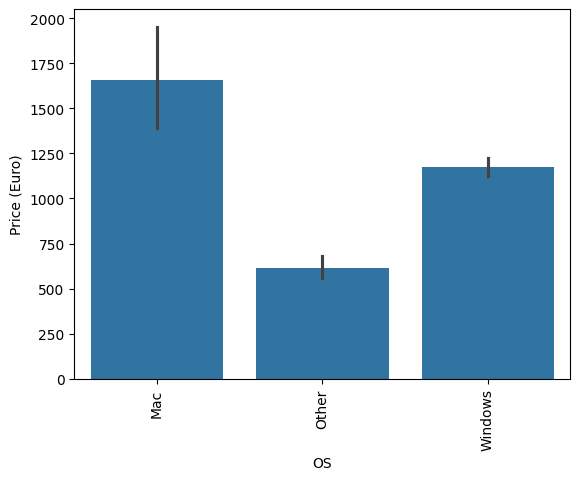

In [159]:
sns.barplot(x=df['OS'],y=df['Price (Euro)'])
plt.xticks(rotation='vertical')
plt.show()

/tmp/ipykernel_3731/3585326794.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Weight (kg)'])


<Axes: xlabel='Weight (kg)', ylabel='Density'>

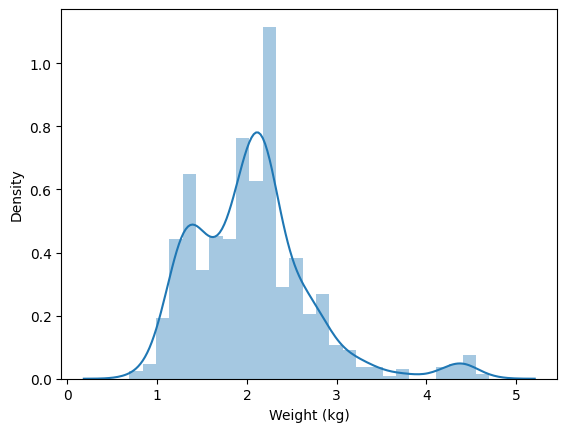

In [160]:
sns.distplot(df['Weight (kg)'])

<Axes: xlabel='Weight (kg)', ylabel='Price (Euro)'>

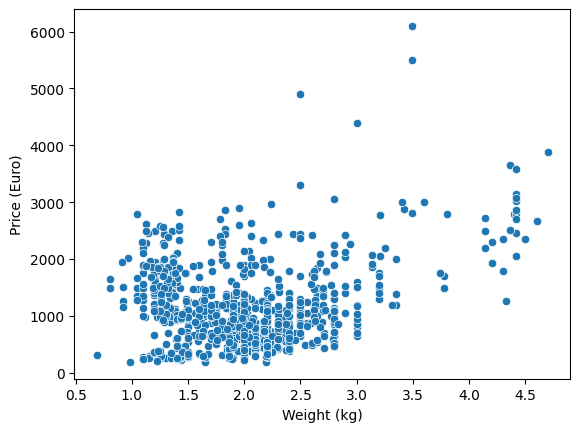

In [161]:
sns.scatterplot(x=df['Weight (kg)'],y=df['Price (Euro)'])

In [162]:
df.corr(numeric_only=True)['Price (Euro)']

,Price (Euro)
CPU_Frequency (GHz),0.451539
RAM (GB),0.784077
Weight (kg),0.241972
Price (Euro),1.000000
Touchscreen,0.198150
Ips,0.232332
ppi,0.490622
HDD,-0.084962
SSD,0.677730


# **EDA**

<Axes: >

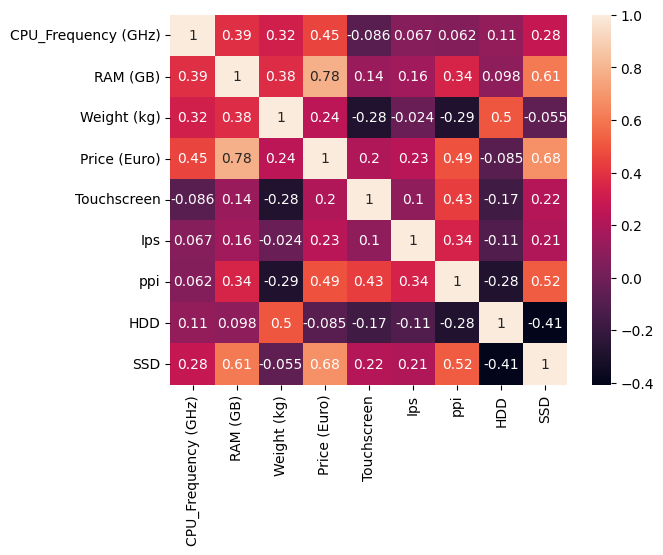

In [163]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

/tmp/ipykernel_3731/565914323.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(np.log(df['Price (Euro)']))


<Axes: xlabel='Price (Euro)', ylabel='Density'>

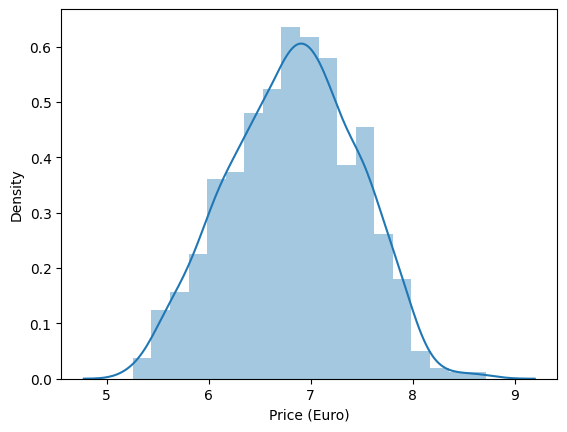

In [164]:
sns.distplot(np.log(df['Price (Euro)']))

In [165]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 881 entries, 0 to 880
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Company              881 non-null    object 
 1   TypeName             881 non-null    object 
 2   CPU_Company          881 non-null    object 
 3   CPU_Frequency (GHz)  881 non-null    float64
 4   RAM (GB)             881 non-null    int64  
 5   GPU_Company          881 non-null    object 
 6   Weight (kg)          881 non-null    float64
 7   Price (Euro)         881 non-null    float64
 8   Touchscreen          881 non-null    int64  
 9   Ips                  881 non-null    int64  
 10  ppi                  881 non-null    float64
 11  CPU                  881 non-null    object 
 12  HDD                  881 non-null    int64  
 13  SSD                  881 non-null    int64  
 14  OS                   881 non-null    object 
dtypes: float64(4), int64(5), object(6)
memor

In [166]:
df['Company'].value_counts()

,count
Company,
Lenovo,207
Dell,205
HP,157
Asus,116
Acer,76
Toshiba,31
MSI,30
Apple,17
Mediacom,7


# **Encoding**

In [167]:
df.nunique(np.dtype==object)

,0
Company,19
TypeName,6
CPU_Company,2
CPU_Frequency (GHz),25
RAM (GB),8
GPU_Company,3
Weight (kg),157
Price (Euro),590
Touchscreen,2
Ips,2


In [168]:
df = pd.get_dummies(df, columns=['Company','TypeName','CPU_Company','GPU_Company','CPU','OS'], drop_first=True)
df_test = pd.get_dummies(df_test, columns=['Company','TypeName','CPU_Company','GPU_Company','CPU','OS'], drop_first=True)

In [169]:
df.head()

,CPU_Frequency (GHz),RAM (GB),Weight (kg),Price (Euro),Touchscreen,Ips,ppi,HDD,SSD,Company_Apple,...,CPU_Core i3,CPU_Core i5,CPU_Core i7,CPU_E-Series,CPU_FX,CPU_Pentium,CPU_Ryzen,CPU_Xeon,OS_Other,OS_Windows
0,2.3,8,1.37,1339.69,0,1,226.983005,0,128,True,...,False,True,False,False,False,False,False,False,False,False
1,1.8,8,1.34,898.94,0,0,127.677940,0,0,True,...,False,True,False,False,False,False,False,False,False,False
2,2.5,8,1.86,575.00,0,0,141.211998,0,256,False,...,False,True,False,False,False,False,False,False,True,False
3,2.7,16,1.83,2537.45,0,1,220.534624,0,512,True,...,False,False,True,False,False,False,False,False,False,False
4,3.1,8,1.37,1803.60,0,1,226.983005,0,256,True,...,False,True,False,False,False,False,False,False,False,False


In [170]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 881 entries, 0 to 880
Data columns (total 52 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CPU_Frequency (GHz)   881 non-null    float64
 1   RAM (GB)              881 non-null    int64  
 2   Weight (kg)           881 non-null    float64
 3   Price (Euro)          881 non-null    float64
 4   Touchscreen           881 non-null    int64  
 5   Ips                   881 non-null    int64  
 6   ppi                   881 non-null    float64
 7   HDD                   881 non-null    int64  
 8   SSD                   881 non-null    int64  
 9   Company_Apple         881 non-null    bool   
 10  Company_Asus          881 non-null    bool   
 11  Company_Chuwi         881 non-null    bool   
 12  Company_Dell          881 non-null    bool   
 13  Company_Fujitsu       881 non-null    bool   
 14  Company_Google        881 non-null    bool   
 15  Company_HP            8

In [171]:
df_test.head()

,CPU_Frequency (GHz),RAM (GB),Weight (kg),Touchscreen,Ips,ppi,HDD,SSD,Company_Apple,Company_Asus,...,CPU_Celeron,CPU_Core M,CPU_Core i3,CPU_Core i5,CPU_Core i7,CPU_E-Series,CPU_FX,CPU_Pentium,OS_Other,OS_Windows
0,2.5,4,2.30,1,0,100.454670,500,0,False,False,...,False,False,False,True,False,False,False,False,False,True
1,1.1,4,1.65,0,0,111.141337,0,0,False,True,...,True,False,False,False,False,False,False,False,False,True
2,2.5,8,2.20,0,1,141.211998,1000,0,False,False,...,False,False,False,False,True,False,False,False,False,True
3,1.6,4,2.20,0,0,100.454670,500,0,False,False,...,False,False,False,False,False,False,False,True,False,True
4,2.5,4,1.28,1,0,165.632118,0,256,False,False,...,False,False,False,True,False,False,False,False,False,True


In [172]:
df_test.shape

(394, 45)

In [173]:
df.head()

,CPU_Frequency (GHz),RAM (GB),Weight (kg),Price (Euro),Touchscreen,Ips,ppi,HDD,SSD,Company_Apple,...,CPU_Core i3,CPU_Core i5,CPU_Core i7,CPU_E-Series,CPU_FX,CPU_Pentium,CPU_Ryzen,CPU_Xeon,OS_Other,OS_Windows
0,2.3,8,1.37,1339.69,0,1,226.983005,0,128,True,...,False,True,False,False,False,False,False,False,False,False
1,1.8,8,1.34,898.94,0,0,127.677940,0,0,True,...,False,True,False,False,False,False,False,False,False,False
2,2.5,8,1.86,575.00,0,0,141.211998,0,256,False,...,False,True,False,False,False,False,False,False,True,False
3,2.7,16,1.83,2537.45,0,1,220.534624,0,512,True,...,False,False,True,False,False,False,False,False,False,False
4,3.1,8,1.37,1803.60,0,1,226.983005,0,256,True,...,False,True,False,False,False,False,False,False,False,False


# **Train-Validation Split 80/20**

In [174]:
X=df.drop(columns=['Price (Euro)'])
y=np.log(df['Price (Euro)'])

In [175]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [176]:
missing_cols = set(X.columns) - set(df_test.columns)
for c in missing_cols:
    df_test[c] = False

extra_cols = set(df_test.columns) - set(X.columns)
df_test = df_test.drop(columns=list(extra_cols))

df_test = df_test[X.columns]

In [177]:
scaler = StandardScaler()
X_train= scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(df_test)

In [178]:
X_train.shape

(704, 51)

In [179]:
X_val.shape

(177, 51)

In [180]:
X_test.shape

(394, 51)

# **Model Implementation**

### **Linear Regression**

In [181]:
model = LinearRegression()
model.fit(X_train,y_train)
y_pred_train = model.predict(X_train)
y_pred_val = model.predict(X_val)

In [182]:
print("Trainig R2 Score")
print(r2_score(y_train ,y_pred_train))
print("Validation R2 Score")
print(r2_score(y_val ,y_pred_val))
print("----------------------")
print("Trainig MSE")
print(mean_squared_error(y_train ,y_pred_train))
print("Validation MSE")
print(mean_squared_error(y_val ,y_pred_val))
print("----------------------")
print("Trainig MAE")
print(mean_absolute_error(y_train ,y_pred_train))
print("Validation MAE")
print(mean_absolute_error(y_val ,y_pred_val))


Trainig R2 Score
0.8796553581139644
Validation R2 Score
0.868355879230702
----------------------
Trainig MSE
0.04481574845578173
Validation MSE
0.05729274447261685
----------------------
Trainig MAE
0.16705649821682272
Validation MAE
0.1901163480247836


### **Polynomial Regression**

### **Ridge Regression**

### **Lasso Regression**

### **Regression Trees**